In [3]:
from gototile.grid import SkyGrid

def load_tiles(file_path: str) -> set:
    tiles = set()
    with open(file_path, 'r') as f:
        for line in f:
            tile_id = line.strip()
            if tile_id:
                tiles.add(tile_id)
    return tiles

In [6]:
grid: SkyGrid = SkyGrid.from_name('GOTO')
heats_tiles = load_tiles("../tile_lists/HEATS.txt")
cold_tiles = set(grid.tilenames) - heats_tiles
cold_tiles -= set(grid.tilenames[:5])  # Remove the south pole
cold_tiles -= set(grid.tilenames[-5:])  # Remove the north pole

print(len(heats_tiles), len(heats_tiles)/len(grid.tilenames))
print(len(cold_tiles), len(cold_tiles)/len(grid.tilenames))

304 0.2900763358778626
734 0.700381679389313


In [25]:
import numpy as np
from astropy import units as u
from astropy.coordinates import AltAz, EarthLocation, SkyCoord, get_sun
from astropy.time import Time, TimeDelta
from time import perf_counter

def simulate_survey(
        start_date, end_date, tel_tile_masks,
        pointing_time=5*60, twilight=-12, min_alt=30,
    ):
    """Simulate a survey over the given time period."""
    start_time = perf_counter()
    print(f'Simulating from {start_date} to {end_date}...')

    # Create sites and grid
    sites = {
        'N': EarthLocation.of_site('lapalma'),
        'S': EarthLocation.of_site('sso'),
    }
    grid = SkyGrid.from_name('GOTO')

    # Run loop over time
    date = start_date
    observations = {t: [] for t in grid.tilenames}
    end_time = perf_counter()
    print(f'  Setup took {end_time - start_time:.2f} seconds.')
    while date < end_date:
        for site in sites:
            # First check if the Sun is above the horizon
            altaz_frame = AltAz(obstime=date, location=sites[site])
            sun = get_sun(date)
        date += TimeDelta(pointing_time * u.s)
    end_time = perf_counter()
    print(f'  Simulation took {end_time - start_time:.2f} seconds.')
    return observations

def simulate_survey_fast(
        start_date, end_date, tel_tile_masks,
        pointing_time=5*60, twilight=-12, min_alt=30,
    ):
    """Simulate a survey over the given time period."""
    start_time = perf_counter()
    print(f'Simulating from {start_date} to {end_date}...')

    # Create sites and grid
    sites = {
        'N': EarthLocation.of_site('lapalma'),
        'S': EarthLocation.of_site('sso'),
    }
    grid = SkyGrid.from_name('GOTO')

    # Run loop over time
    date = start_date
    observations = {t: [] for t in grid.tilenames}
    start_mjd = start_date.mjd
    end_mjd = end_date.mjd
    total_steps = int((end_mjd - start_mjd) * 86400 / pointing_time)
    times = Time(
        start_mjd + np.arange(total_steps) * pointing_time / 86400,
        format='mjd'
    )
    # Get sun position for all times
    sun_coords = get_sun(times)
    sun_altaz_dict = {}
    for site_key, site_location in sites.items():
        sun_altaz = sun_coords.transform_to(
            AltAz(obstime=times, location=site_location)
        )
        sun_altaz_dict[site_key] = sun_altaz
    lst_N = times.sidereal_time('apparent', sites['N'].lon)
    lst_S = times.sidereal_time('apparent', sites['S'].lon)
    end_time = perf_counter()
    print(f'  Setup took {end_time - start_time:.2f} seconds.')

    for date in times:
        for site in sites:
            if sun_altaz_dict[site][times == date].alt.deg > twilight:
                continue  # Skip if sun is above twilight limit

        pass  # Placeholder for the actual simulation logic
    end_time = perf_counter()
    print(f'  Simulation took {end_time - start_time:.2f} seconds.')
    return observations

In [26]:
start_date = Time('2025-11-18 16:00')  # End of O4
end_date = Time('2025-12-18 16:00')

# Define which tiles each telescope can observe
heats_mask = np.array([tile in heats_tiles for tile in grid.tilenames])
cold_mask = np.array([tile in cold_tiles for tile in grid.tilenames])
tel_tile_masks = {
    1: heats_mask,
    2: cold_mask,
    3: heats_mask,
    4: cold_mask,
}

# Run the simulation
observations = simulate_survey(start_date, end_date, tel_tile_masks)

Simulating from 2025-11-18 16:00:00.000 to 2025-12-18 16:00:00.000...
  Setup took 0.23 seconds.
  Simulation took 36.70 seconds.


In [27]:
# Run the simulation
observations = simulate_survey_fast(start_date, end_date, tel_tile_masks)

Simulating from 2025-11-18 16:00:00.000 to 2025-12-18 16:00:00.000...
  Setup took 3.74 seconds.
  Simulation took 3.91 seconds.


In [31]:
start_mjd = start_date.mjd
end_mjd = end_date.mjd
pointing_time = 300
total_steps = int((end_mjd - start_mjd) * 86400 / pointing_time)
times = Time(
    start_mjd + np.arange(total_steps) * pointing_time / 86400,
    format='mjd'
)

array([0.])

In [108]:
sidereal_times = times.sidereal_time('apparent', EarthLocation.of_site('lapalma'))
sidereal_times
# Round sidereal times to nearest second (angle)
sidereal_times_rounded = sidereal_times.round(3)  #
print(len(sidereal_times), len(set(sidereal_times_rounded)))

8640 7597


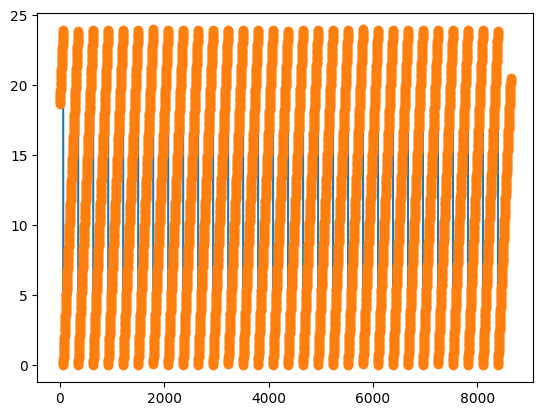

In [109]:
import matplotlib.pyplot as plt
plt.plot(sidereal_times)
plt.plot(sidereal_times_rounded, 'o')

In [110]:
sidereal_times.hour

array([18.67137281, 18.75493431, 18.8384958 , ..., 20.39200993,
       20.47557143, 20.55913293])

In [111]:
sidereal_times_rounded.hour

array([18.671, 18.755, 18.838, ..., 20.392, 20.476, 20.559])

In [112]:
# Find average time between sidereal time and rounded sidereal time
time_diffs = sidereal_times - sidereal_times_rounded
avg_diff = np.mean(np.abs(time_diffs))
print(avg_diff)

0h00m00.90000225s


In [130]:
# For each unique rounded sidereal time, find the position of each tile
from astropy.coordinates import Angle, HADec
unique_sidereal_times = Angle(sorted(set(sidereal_times_rounded)), unit=u.hourangle)

# We have SkyCoords for each tile from grid.coords, we can transform them to AltAz for each unique sidereal time
tile_altaz_dict = {}
coords = grid.coords
# Create a matrix of hour angles for each tile and each unique sidereal time
def compute_hour_angles(coords: SkyCoord, unique_sidereal_times: Angle) -> np.ndarray:
    hour_angles = np.zeros((len(unique_sidereal_times), len(coords))) * u.deg
    for i, lst in enumerate(unique_sidereal_times):
        hour_angles[i] = lst - coords.ra
    return hour_angles
hour_angles = compute_hour_angles(coords, unique_sidereal_times)
hour_angles

<Quantity [[ 1.50000e-02, -7.19850e+01, -1.43985e+02, ..., -1.43985e+02,
            -2.15985e+02, -2.87985e+02],
           [ 3.00000e-02, -7.19700e+01, -1.43970e+02, ..., -1.43970e+02,
            -2.15970e+02, -2.87970e+02],
           [ 4.50000e-02, -7.19550e+01, -1.43955e+02, ..., -1.43955e+02,
            -2.15955e+02, -2.87955e+02],
           ...,
           [ 3.59865e+02,  2.87865e+02,  2.15865e+02, ...,  2.15865e+02,
             1.43865e+02,  7.18650e+01],
           [ 3.59940e+02,  2.87940e+02,  2.15940e+02, ...,  2.15940e+02,
             1.43940e+02,  7.19400e+01],
           [ 3.59955e+02,  2.87955e+02,  2.15955e+02, ...,  2.15955e+02,
             1.43955e+02,  7.19550e+01]] deg>

In [131]:
hour_angles[0].shape

(1048,)

In [132]:
hour_angles[0]

<Quantity [ 1.50000e-02, -7.19850e+01, -1.43985e+02, ..., -1.43985e+02,
           -2.15985e+02, -2.87985e+02] deg>

In [133]:
hadec = HADec(ha=hour_angles, dec=coords.dec, location=EarthLocation.of_site('lapalma'))
hadec[750]


<HADec Coordinate (obstime=None, location=(5327448.9957829, -1718665.73869569, 3051566.90295403) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (ha, dec) in (hourangle, deg)
    [( 2.366, -87.35), (-2.434, -87.35), (-7.234, -87.35), ...,
     (-7.234,  87.35), (11.966,  87.35), ( 7.166,  87.35)]>

In [164]:
# Get altitude from HADec
def hadec_to_altitude(hadec: HADec) -> Angle:
    altitude = np.atan2(np.sin(hadec.ha.rad))
    return altitude
altitudes = hadec_to_altitude(hadec)
altitudes

<Angle [[-0.45567638, -0.48710165, -0.53912653, ...,  0.46432228,
          0.46430833,  0.51566876],
        [-0.45567639, -0.48709023, -0.53911925, ...,  0.46432926,
          0.46430136,  0.51565716],
        [-0.45567639, -0.48707882, -0.53911198, ...,  0.46433624,
          0.46429439,  0.51564556],
        ...,
        [-0.4556765 , -0.4872159 , -0.5391991 , ...,  0.46425263,
          0.46437819,  0.51578473],
        [-0.4556764 , -0.48715876, -0.53916285, ...,  0.46428742,
          0.46434323,  0.51572676],
        [-0.45567639, -0.48714734, -0.53915559, ...,  0.46429439,
          0.46433624,  0.51571516]] rad>

In [165]:
# Compare altitudes with the values obtained from transforming to AltAz directly
idx = 0

altaz = coords.transform_to(
    AltAz(obstime=times[idx], location=EarthLocation.of_site('lapalma'))
)
# Remove negative altitudes for comparison
altaz = altaz[altaz.alt.deg >= 0]
altitudes = altitudes[idx][altitudes[idx].deg >= 0]

In [166]:
diff = altitudes[idx] - altaz.alt
diff.deg

array([ 3.38049363e-01,  8.00624891e-02, -1.77783896e-02, -3.11242310e+00,
       -4.89646232e+00, -5.27398254e+00, -4.22374569e+00, -1.80388597e+00,
       -1.04280055e-01, -4.43458423e+00, -7.71669087e+00, -9.80692480e+00,
       -1.06022665e+01, -1.00608334e+01, -8.21124360e+00, -5.14615268e+00,
       -1.00325377e+00, -4.44905564e+00, -8.83393846e+00, -1.22726748e+01,
       -1.46268275e+01, -1.57873701e+01, -1.56956169e+01, -1.43562968e+01,
       -1.18364525e+01, -8.25072477e+00, -3.74000780e+00, -3.63742057e+00,
       -8.77987015e+00, -1.32064900e+01, -1.67806149e+01, -1.93674726e+01,
       -2.08524600e+01, -2.11621289e+01, -2.02803613e+01, -1.82522086e+01,
       -1.51734210e+01, -1.11708862e+01, -6.38220492e+00, -9.40302727e-01,
        7.52812936e-02, -5.87465956e+00, -1.13163898e+01, -1.61324581e+01,
       -2.01888138e+01, -2.33428399e+01, -2.54591194e+01, -2.64318727e+01,
       -2.62078040e+01, -2.47994265e+01, -2.22818221e+01, -1.87746242e+01,
       -1.44182606e+01, -

(array([ 7., 20., 33., 40., 53., 67., 69., 78., 78., 83.]),
 array([-88.55785174, -79.66623057, -70.7746094 , -61.88298824,
        -52.99136707, -44.0997459 , -35.20812473, -26.31650356,
        -17.42488239,  -8.53326122,   0.35835995]),
 <BarContainer object of 10 artists>)

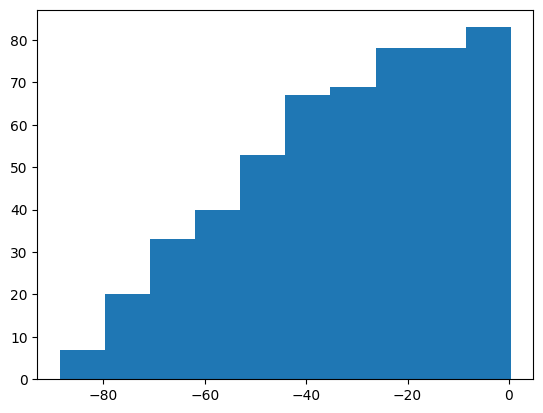

In [167]:
plt.hist(diff.deg)

In [169]:
altaz = coords[0].transform_to(
    AltAz(obstime=times, location=EarthLocation.of_site('lapalma'))
)

In [171]:
# Create a grid of sidereal times across the whole angle range (0 to 24 hours) with 1 second resolution
sidereal_time_grid = Angle(np.arange(0, 24*3600) / 3600, unit=u.hourangle)
#Calculate hour angles for each tile and each sidereal time in the grid
hour_angles_grid = compute_hour_angles(coords, sidereal_time_grid)

In [ ]:
# Convert hour angles to altitudes
